# 📈 Support Vector Regression (SVR) - Complete Learning Guide

## Overview
Support Vector Regression extends SVM to regression problems. It uses epsilon-insensitive loss to fit data while controlling model complexity. SVR is powerful for non-linear regression with proper kernel selection.

## Key Topics Covered:
1. **SVR Basics** - Support vectors for regression
2. **Epsilon-Insensitive Loss** - SVR loss function
3. **Kernels for SVR** - Linear, RBF, Polynomial
4. **Regularization (C)** - Controlling model complexity
5. **Epsilon Parameter** - Tolerance margin
6. **Feature Scaling** - Importance for distance metrics
7. **Hyperparameter Tuning** - Optimal C, gamma, epsilon
8. **Advantages & Disadvantages** - When to use SVR

---

## References:
- [SVR - scikit-learn](https://scikit-learn.org/stable/modules/svm.html#regression)
- [Support Vector Regression](https://en.wikipedia.org/wiki/Support_vector_machine#Regression)
- [SVR Tutorial](https://www.youtube.com/watch?v=kNV5ljFwQvA)

## 📚 Section 1: Import Libraries

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📈 Section 2: SVR Basics


📈 EXAMPLE 1: Basic Support Vector Regression

✅ SVR Results (kernel=RBF, C=100, gamma=0.1):
  MSE:  474.2492
  RMSE: 21.7773
  MAE:  17.4584
  R²:   0.7746
  Number of support vectors: 51


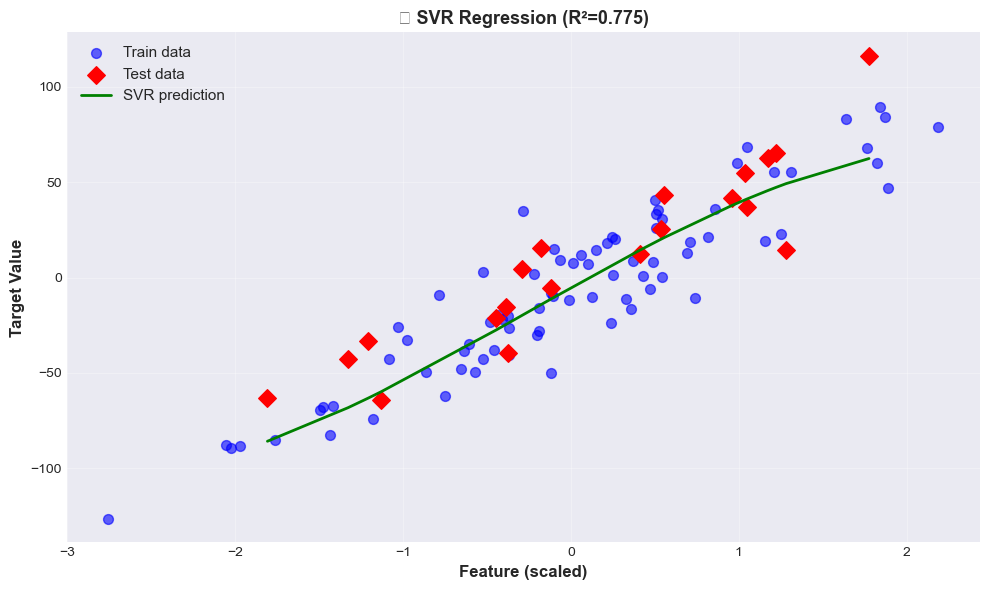

In [2]:
# Example 1: Basic SVR
print("\n" + "="*70)
print("📈 EXAMPLE 1: Basic Support Vector Regression")
print("="*70)

# Create synthetic regression data
X, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVR model
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=10)
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n✅ SVR Results (kernel=RBF, C=100, gamma=0.1):")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R²:   {r2:.4f}")
print(f"  Number of support vectors: {len(svr.support_vectors_)}")

# Visualization
X_test_sorted = X_test_scaled[np.argsort(X_test_scaled[:, 0])]
y_test_sorted = y_test[np.argsort(X_test_scaled[:, 0])]
y_pred_sorted = svr.predict(X_test_sorted)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_train_scaled, y_train, c='blue', label='Train data', s=50, alpha=0.6)
ax.scatter(X_test_sorted, y_test_sorted, c='red', label='Test data', s=80, marker='D')
ax.plot(X_test_sorted, y_pred_sorted, 'g-', linewidth=2, label='SVR prediction')

ax.set_xlabel('Feature (scaled)', fontsize=12, fontweight='bold')
ax.set_ylabel('Target Value', fontsize=12, fontweight='bold')
ax.set_title(f'📈 SVR Regression (R²={r2:.3f})', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🔗 Section 3: Comparing Kernels


🔗 EXAMPLE 2: Comparing SVR Kernels

📊 Testing different kernels:
  linear  : R²=0.7952, RMSE=20.7605
  rbf     : R²=0.7993, RMSE=20.5504
  poly    : R²=0.3801, RMSE=36.1144


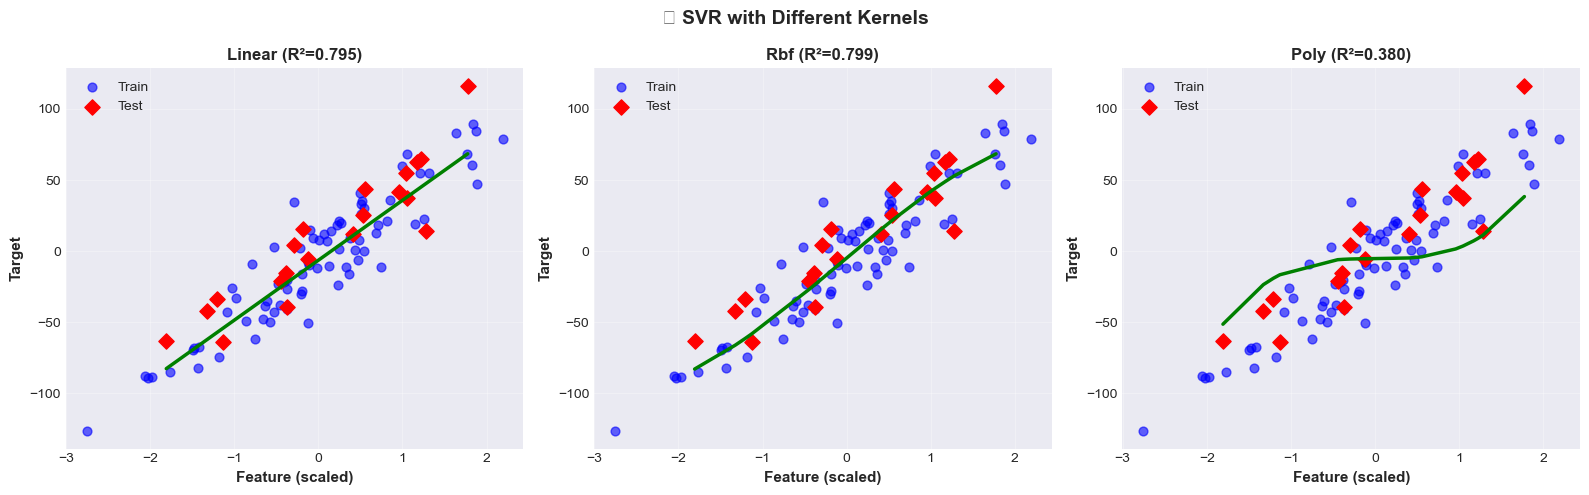

In [3]:
# Example 2: Different Kernels
print("\n" + "="*70)
print("🔗 EXAMPLE 2: Comparing SVR Kernels")
print("="*70)

kernels = ['linear', 'rbf', 'poly']
results = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('🔗 SVR with Different Kernels', fontsize=14, fontweight='bold')

print(f"\n📊 Testing different kernels:")
for idx, kernel in enumerate(kernels):
    if kernel == 'poly':
        svr_kernel = SVR(kernel=kernel, C=100, gamma=0.1, degree=3)
    else:
        svr_kernel = SVR(kernel=kernel, C=100, gamma=0.1)
    
    svr_kernel.fit(X_train_scaled, y_train)
    y_pred_kernel = svr_kernel.predict(X_test_scaled)
    
    r2_kernel = r2_score(y_test, y_pred_kernel)
    rmse_kernel = np.sqrt(mean_squared_error(y_test, y_pred_kernel))
    
    results[kernel] = {'r2': r2_kernel, 'rmse': rmse_kernel}
    print(f"  {kernel:8s}: R²={r2_kernel:.4f}, RMSE={rmse_kernel:.4f}")
    
    # Plot
    ax = axes[idx]
    y_pred_sorted_kernel = svr_kernel.predict(X_test_sorted)
    
    ax.scatter(X_train_scaled, y_train, c='blue', s=40, alpha=0.6, label='Train')
    ax.scatter(X_test_sorted, y_test_sorted, c='red', s=60, marker='D', label='Test')
    ax.plot(X_test_sorted, y_pred_sorted_kernel, 'g-', linewidth=2.5)
    
    ax.set_xlabel('Feature (scaled)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Target', fontsize=11, fontweight='bold')
    ax.set_title(f'{kernel.capitalize()} (R²={r2_kernel:.3f})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🎯 Section 4: Impact of C and Epsilon


🎯 EXAMPLE 3: Impact of C and Epsilon Parameters

📊 Impact of C (regularization):
  C=   0.1: R²=-0.0522
  C=   1.0: R²=0.1728
  C=  10.0: R²=0.7601
  C= 100.0: R²=0.7746
  C=1000.0: R²=0.7851

📊 Impact of Epsilon (tolerance margin):
  Epsilon= 1: R²=0.8023
  Epsilon= 5: R²=0.7908
  Epsilon=10: R²=0.7746
  Epsilon=20: R²=0.7956
  C=   0.1: R²=-0.0522
  C=   1.0: R²=0.1728
  C=  10.0: R²=0.7601
  C= 100.0: R²=0.7746
  C=1000.0: R²=0.7851

📊 Impact of Epsilon (tolerance margin):
  Epsilon= 1: R²=0.8023
  Epsilon= 5: R²=0.7908
  Epsilon=10: R²=0.7746
  Epsilon=20: R²=0.7956


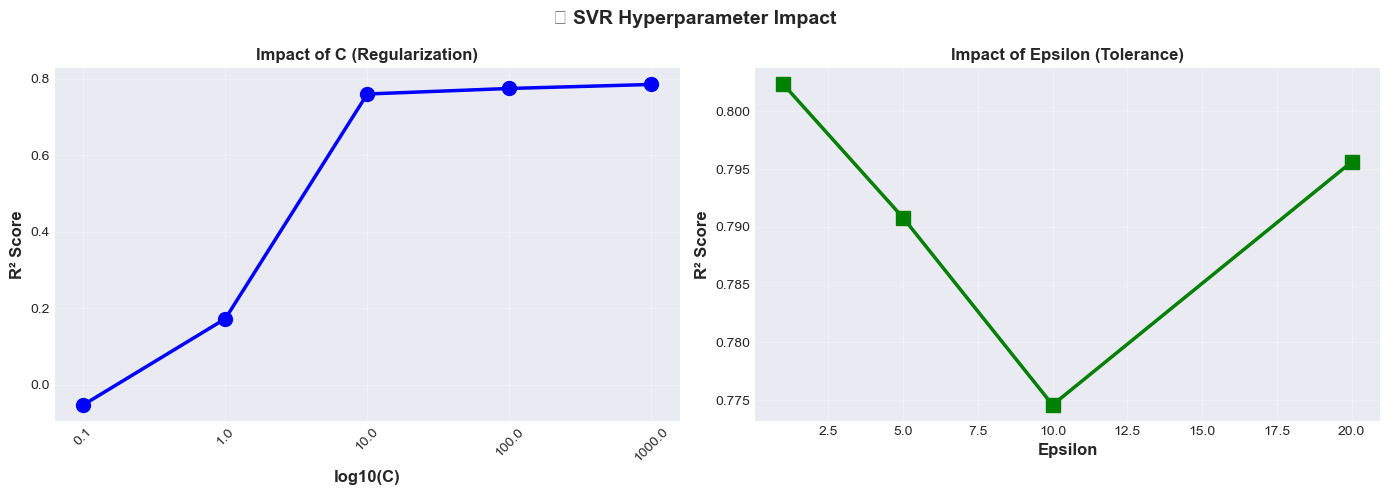

In [4]:
# Example 3: Hyperparameter Impact
print("\n" + "="*70)
print("🎯 EXAMPLE 3: Impact of C and Epsilon Parameters")
print("="*70)

C_values = [0.1, 1, 10, 100, 1000]
epsilon_values = [1, 5, 10, 20]

results_c = []
results_eps = []

print(f"\n📊 Impact of C (regularization):")
for c in C_values:
    svr_c = SVR(kernel='rbf', C=c, gamma=0.1, epsilon=10)
    svr_c.fit(X_train_scaled, y_train)
    r2_c = svr_c.score(X_test_scaled, y_test)
    results_c.append(r2_c)
    print(f"  C={c:6.1f}: R²={r2_c:.4f}")

print(f"\n📊 Impact of Epsilon (tolerance margin):")
for eps in epsilon_values:
    svr_eps = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=eps)
    svr_eps.fit(X_train_scaled, y_train)
    r2_eps = svr_eps.score(X_test_scaled, y_test)
    results_eps.append(r2_eps)
    print(f"  Epsilon={eps:2d}: R²={r2_eps:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🎯 SVR Hyperparameter Impact', fontsize=14, fontweight='bold')

# C impact
ax = axes[0]
ax.plot(np.log10(C_values), results_c, 'o-', linewidth=2.5, markersize=10, color='blue')
ax.set_xlabel('log10(C)', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('Impact of C (Regularization)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(np.log10(C_values))
ax.set_xticklabels([f'{c:.1f}' for c in C_values], rotation=45)

# Epsilon impact
ax = axes[1]
ax.plot(epsilon_values, results_eps, 's-', linewidth=2.5, markersize=10, color='green')
ax.set_xlabel('Epsilon', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('Impact of Epsilon (Tolerance)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🔧 Section 5: Hyperparameter Tuning


🔧 EXAMPLE 4: GridSearchCV for SVR

🔍 Performing GridSearchCV...

✅ Best Parameters: {'C': 10, 'epsilon': 5, 'gamma': 0.01, 'kernel': 'linear'}
  Best CV Score: 0.8397

✅ Best Model Test Performance:
  R²:   0.7905
  RMSE: 20.9931

✅ Best Parameters: {'C': 10, 'epsilon': 5, 'gamma': 0.01, 'kernel': 'linear'}
  Best CV Score: 0.8397

✅ Best Model Test Performance:
  R²:   0.7905
  RMSE: 20.9931


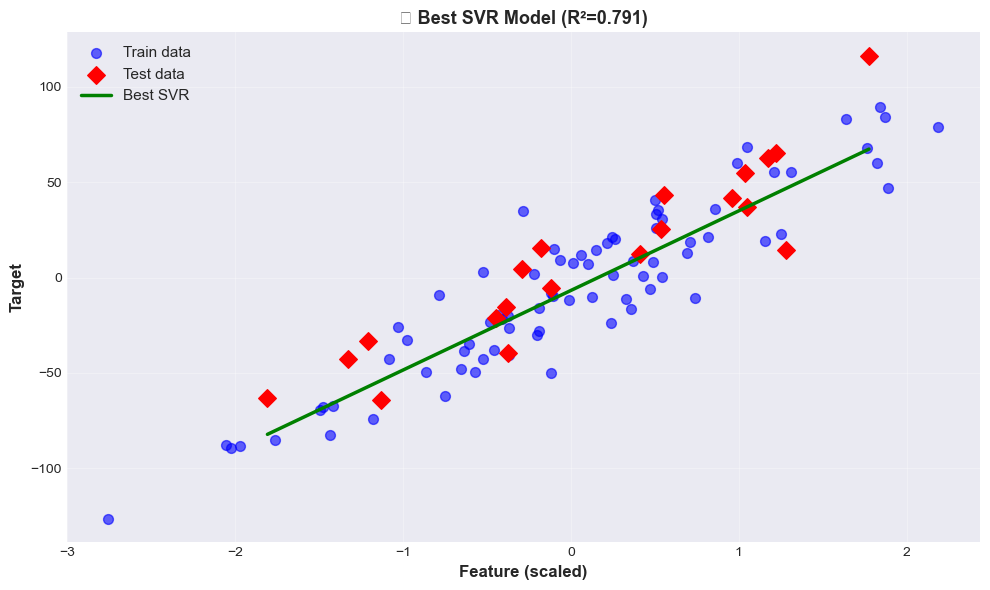

In [5]:
# Example 4: GridSearchCV
print("\n" + "="*70)
print("🔧 EXAMPLE 4: GridSearchCV for SVR")
print("="*70)

param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1],
    'epsilon': [5, 10, 20]
}

print(f"\n🔍 Performing GridSearchCV...")
grid_search = GridSearchCV(
    SVR(),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"  Best CV Score: {grid_search.best_score_:.4f}")

best_svr = grid_search.best_estimator_
y_pred_best = best_svr.predict(X_test_scaled)
r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"\n✅ Best Model Test Performance:")
print(f"  R²:   {r2_best:.4f}")
print(f"  RMSE: {rmse_best:.4f}")

# Plot best model
y_pred_best_sorted = best_svr.predict(X_test_sorted)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_train_scaled, y_train, c='blue', label='Train data', s=50, alpha=0.6)
ax.scatter(X_test_sorted, y_test_sorted, c='red', label='Test data', s=80, marker='D')
ax.plot(X_test_sorted, y_pred_best_sorted, 'g-', linewidth=2.5, label='Best SVR')

ax.set_xlabel('Feature (scaled)', fontsize=12, fontweight='bold')
ax.set_ylabel('Target', fontsize=12, fontweight='bold')
ax.set_title(f'🔧 Best SVR Model (R²={r2_best:.3f})', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📋 Section 6: SVR - Advantages & Disadvantages

### ✅ Advantages:
1. **Kernel flexibility** - Non-linear regression via kernels
2. **Robust** - Less sensitive to outliers than linear regression
3. **Epsilon-insensitive** - Tolerance margin for flexibility
4. **Works in high dimensions** - Efficient in high-dimensional spaces
5. **Bounded support vectors** - Sparse solutions
6. **Good generalization** - Margin-based learning

### ❌ Disadvantages:
1. **Hyperparameter tuning** - Needs C, gamma, epsilon selection
2. **Computational cost** - O(n³) training complexity
3. **Requires scaling** - Features need standardization
4. **Difficult interpretation** - Black box model
5. **Sensitive parameters** - Performance varies with tuning
6. **Doesn't handle missing data** - Preprocessing needed

### When to Use:
- Non-linear regression needed
- High-dimensional data
- Small to medium datasets (<10k)
- When robust to outliers important
- Complex non-linear relationships

In [6]:
# Example 5: Summary
print("\n" + "="*70)
print("🎓 KEY TAKEAWAYS")
print("="*70)

takeaways = [
    "SVR: Support Vector Machine adapted for regression tasks",
    "Uses epsilon-insensitive loss: Ignores errors < epsilon",
    "Kernels enable non-linear regression (RBF, Polynomial, etc.)",
    "C parameter: Regularization (large C = fit data tightly)",
    "Epsilon parameter: Tolerance margin around predictions",
    "Gamma parameter: RBF kernel width (high = flexible, low = simple)",
    "Always scale features! Distance metrics scale-dependent",
    "Support vectors: Only relevant training points matter",
    "Robust to outliers: Epsilon-insensitive loss helps",
    "Computational cost: O(n³) - slower for large datasets",
    "GridSearchCV essential: Parameters heavily affect performance",
    "Good for complex non-linear patterns with tuning"
]

for i, takeaway in enumerate(takeaways, 1):
    print(f"\n{i:2d}. {takeaway}")

print(f"\n" + "="*70)


🎓 KEY TAKEAWAYS

 1. SVR: Support Vector Machine adapted for regression tasks

 2. Uses epsilon-insensitive loss: Ignores errors < epsilon

 3. Kernels enable non-linear regression (RBF, Polynomial, etc.)

 4. C parameter: Regularization (large C = fit data tightly)

 5. Epsilon parameter: Tolerance margin around predictions

 6. Gamma parameter: RBF kernel width (high = flexible, low = simple)

 7. Always scale features! Distance metrics scale-dependent

 8. Support vectors: Only relevant training points matter

 9. Robust to outliers: Epsilon-insensitive loss helps

10. Computational cost: O(n³) - slower for large datasets

11. GridSearchCV essential: Parameters heavily affect performance

12. Good for complex non-linear patterns with tuning

